# Lab 08: Airline Tweets Sentiment Analysis

---
author: Isabella Iniguez
date: November 18, 2024
embed-resources: true
---

## Introduction

In this report, we develop a classification model that predicts if a given twitter post ("tweet") is one of negative, neutral, or positive sentiment. By building this model, we aim to build a sentiment classifier that will alert airline customer service representatives to respond to negative tweets about the airline and for positive tweets to be automatically acknowledged.

## Methods

In [30]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Data

In [50]:
# load data
tweets = pd.read_csv(
    "https://cs307.org/lab-08/data/tweets.csv",
)

tweets_train, tweets_test = train_test_split(
    tweets,
    test_size=0.25,
    random_state=42,
)

tweets_train

,sentiment,airline,text
2233,positive,Delta,@JetBlue Then en route to the airport the rebo...
10733,negative,United,@united now you've lost my bags too. At least...
400,neutral,US Airways,"@USAirways Hi, can you attach my AA FF# 94LXA6..."
7615,positive,United,"@United, will you fill it? Yes they will. Than..."
4099,negative,American,@AmericanAir thanks! I hope we get movies. Tv'...
...,...,...,...
5734,negative,United,@united Can i get a refund? I would like to bo...
5191,neutral,Virgin America,@VirginAmerica what is your policy on flying a...
5390,negative,United,@united I'm not sure how you can help. Your fl...
860,neutral,Virgin America,@VirginAmerica LAX to EWR - Middle seat on a r...


### Data Dictionary

Each observation in the train and test data contains information about a particular traveler's tweet.

The variables considered are:

#### Response

`sentiment`
-   `[object]` the sentiment of the tweet. One of negative, neutral, or positive.

#### Features

`text`
-   `[object]` the full text of the tweet.

#### Additional Variables

`airline`
-   `[object]` the airline the tweet was “sent” to.

In [33]:
# summary statistics
print("Number of Samples: ", len(tweets_train))
print("Number of Features: ", len(tweets_train.columns) - 1)

Number of Samples:  8235
Number of Features:  2


In [51]:
# Airline Tweet Counts and Proportions
a = tweets_train.groupby("airline").agg("count").rename(columns={'sentiment':'count', 'text': 'proportion'})
a["proportion"] = a["proportion"] / len(tweets_train)
a

,count,proportion
airline,,
American,1551,0.188342
Delta,1239,0.150455
Southwest,1347,0.163570
US Airways,1664,0.202064
United,2166,0.263024
Virgin America,268,0.032544


In [35]:
# Word Occurrences
top_100_counter = CountVectorizer(max_features=100)
X_top_100 = top_100_counter.fit_transform(tweets_train['text'])
plane_idx = np.where(top_100_counter.get_feature_names_out() == "cancelled")
plane_count = np.sum(X_top_100.todense()[:, plane_idx])
print('The Word "cancelled" Appears:', plane_count)
plane_idx = np.where(top_100_counter.get_feature_names_out() == "please")
plane_count = np.sum(X_top_100.todense()[:, plane_idx])
print('The Word "please" Appears:', plane_count)
plane_idx = np.where(top_100_counter.get_feature_names_out() == "thanks")
plane_count = np.sum(X_top_100.todense()[:, plane_idx])
print('The Word "thanks" Appears:', plane_count)

The Word "cancelled" Appears: 595
The Word "please" Appears: 325
The Word "thanks" Appears: 587


In [52]:
# Tweet Sentiment Count
tweets_train[['airline','sentiment']].groupby('sentiment').agg('count').rename(columns={'airline':'count'})

,count
sentiment,
negative,5118
neutral,1810
positive,1307


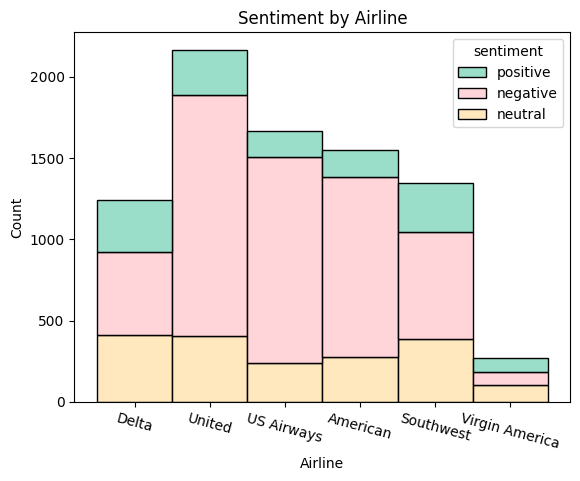

In [53]:
# Visualizations
sns.histplot(data=tweets_train, x='airline', hue='sentiment', multiple='stack', 
             palette={'positive': '#79d4b7',  
                      'neutral': '#ffe0a8',  
                      'negative': '#ffc7ce'})
plt.xticks(rotation=-15) 
plt.xlabel("Airline")
plt.title("Sentiment by Airline")
plt.show()

When analyzing the data, one of the first things we notice is that we have far less tweet data from Virgin America to reference (3% of the data) in comparison to the other airlines (15% - 26% of the data each). This may suggest some issues with being able to distinguish trends in tweet sentiments under that specific airline.

The histogram visualization of the data shows a difference in representation between sentiment categories across all airlines. Most of the airlines have significantly more negative tweets and barely positive or negative ones. This may suggest some issues with being able to distinguish between the categories, likely resulting in misclassifying the less represented categories as negative. Since we still have a significant number of these less represented observations (1810 neutral and 1307 positive), it may not have as big of an impact on the overall accuracy.

### Models

In [37]:
# process data for ML
# create X and y for train data
X_train = tweets_train["text"]
y_train = tweets_train["sentiment"]

# create X and y for test data
X_test = tweets_test["text"]
y_test = tweets_test["sentiment"]

In [38]:
pipeline = Pipeline(
    steps=[
        ("vectorizer", TfidfVectorizer(max_features=100)),
        ("regressor", LogisticRegression(penalty=None, max_iter=500)),
    ]
)

pipeline

Pipeline(steps=[('vectorizer', TfidfVectorizer(max_features=100)),
                ('regressor', LogisticRegression(max_iter=500, penalty=None))])

In [39]:
# define parameter grid
param_grid = {
    "vectorizer__max_features": [1750, 2000, 2250],
    "vectorizer__stop_words": [None, 'english'],
    "vectorizer__min_df": [10], 
    "vectorizer__ngram_range": [(1,1), (1,2), (1,3), (2,3)], 
    "regressor__penalty": ["l2"], 
    "regressor__solver": ["saga"], 
    "regressor__C": [0.5, 0.75, 1, 1.25, 1.5],
    "regressor__random_state": [307],
}

In [40]:
# setup grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", refit="f1")

In [41]:
# run grid search with cross-validation
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vectorizer',
                                        TfidfVectorizer(max_features=100)),
                                       ('regressor',
                                        LogisticRegression(max_iter=500,
                                                           penalty=None))]),
             param_grid={'regressor__C': [0.5, 0.75, 1, 1.25, 1.5],
                         'regressor__penalty': ['l2'],
                         'regressor__random_state': [307],
                         'regressor__solver': ['saga'],
                         'vectorizer__max_features': [1750, 2000, 2250],
                         'vectorizer__min_df': [10],
                         'vectorizer__ngram_range': [(1, 1), (1, 2), (1, 3),
                                                     (2, 3)],
                         'vectorizer__stop_words': [None, 'english']},
             refit='f1', scoring='accuracy')

In [42]:
# print best parameters found and best (cross-validated) score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_}")

Best parameters: {'regressor__C': 1.25, 'regressor__penalty': 'l2', 'regressor__random_state': 307, 'regressor__solver': 'saga', 'vectorizer__max_features': 2250, 'vectorizer__min_df': 10, 'vectorizer__ngram_range': (1, 2), 'vectorizer__stop_words': None}
Best cross-validation accuracy: 0.7829993928354584


Here we used a tuning pipeline to try and find the best cross-validated logistic regression model.

## Results

In [43]:
# report model metrics
# final evaluation on test set
y_pred = grid_search.predict(X_test)
print(f"Test set accuracy: {accuracy_score(y_test, y_pred)}")

Test set accuracy: 0.7919854280510018


Our model achieved a test accuracy of 0.792.

## Discussion

Given that the model achieved a test accuracy of 79.2%, this model appears to be a decently good predictor of tweet sentiment. However, given that the model is not infallible, we have to address these potential classification mistakes and their impact on the businesses.

Misclassifying a negative tweet as neutral or positive could lead to the airline missing an opportunity to address customers’ concerns. This leads to the airline appearing unresponsive, or at worst, negligent. Further escalating, there may be public criticism or loss of customer’s trust in the worst cases, leading to overall negative loss in rapport and business. This is likely the most severe of mistakes, and thus should be deeply considered if this model was to be used.

Misclassifying a neutral or positive tweet as negative might cause the airline to unnecessarily redirect resources to be spent on addressing non-critical or non-existent issues, negatively impacting its operational efficiency and service. As such, these changes can possibly perpetuate even more complaints in the newly mismanaged areas. However, if the alerted customer service representative interprets the tweet correctly as intended, such misunderstanding would be avoided. As long as customer service is present in the process, these mistakes should not be of much severity.

Misclassifying neutral tweets as either positive or negative would not be as impactful since neutral sentiments often carry little actionable value to a business. There is nothing to improve on or maintain, so there is little to no severity in these mistakes,

Given the confusion matrix below, it is shown that the model’s most common error is misclassifying a neutral or positive tweet as negative. Thus, as stated previously, the severity of these mistakes would be mitigated given the expected customer service representative’s review of such tweets. All other mistakes are less frequent, but still exist.


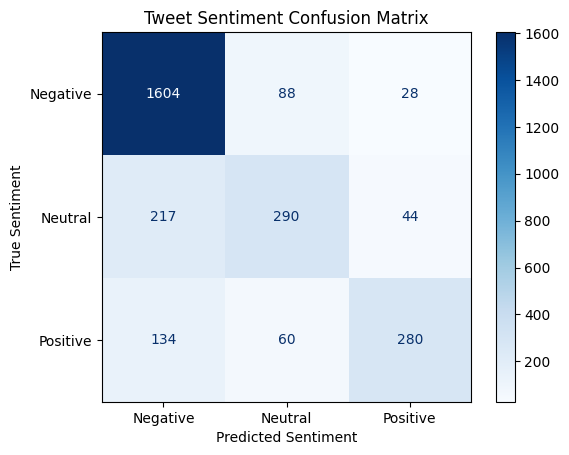

In [44]:
y_pred = grid_search.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Neutral', 'Positive'])
disp.plot(cmap="Blues")
plt.xlabel("Predicted Sentiment")
plt.ylabel("True Sentiment")
plt.title("Tweet Sentiment Confusion Matrix")
plt.show()

### Conclusion

Given the performance and expected human assistance, I would recommend this model for use.

In [ ]:
from joblib import dump
dump(grid_search, "airline-sentiment.joblib")